In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# load dataset
df = pd.read_csv("Crime_Data_Premise_Severity.csv")
df.head()

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Day_of_Week,Is_Weekend,Premise_Category,Crime_Severity_Desc
0,2021-04-11,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,...,0.0,0.0,7800 BEEMAN AV,Not Reported,34.2124,-118.4092,Saturday,1,Residential,Medium
1,2020-10-21,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,0.0,0.0,ATOLL AV,N GAULT,34.1993,-118.4203,Sunday,1,Public/Street,Severe
2,2024-12-10,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,...,0.0,0.0,14600 SYLVAN ST,Not Reported,34.1847,-118.4509,Friday,0,Residential,Medium
3,2020-12-24,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,...,0.0,0.0,6000 COMEY AV,Not Reported,34.0339,-118.3747,Thursday,0,Public/Street,Medium
4,2020-10-03,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,0.0,0.0,4700 LA VILLA MARINA,Not Reported,33.9813,-118.4350,Tuesday,0,Public/Street,Medium


In [22]:
# missing ML feature
df['hour'] = df['TIME OCC'] // 100

In [23]:
df['Weapon Used'] = df['Weapon Desc'].apply(lambda x: 0 if x == 'Unknown' else 1)

In [24]:
# for model stability
df = df[(df['Vict Age'] > 0) & (df['Vict Age'] <= 100)]

In [25]:
# reducing classes
top_crimes = df['Crm Cd Desc'].value_counts().head(8).index
df = df[df['Crm Cd Desc'].isin(top_crimes)]

In [26]:
# define features and target
X = df[['AREA NAME','hour','Day_of_Week','Is_Weekend',
        'Premise_Category','Crime_Severity_Desc',
        'Vict Age','Vict Sex','Weapon Used']]

y = df['Crm Cd Desc']

In [27]:
# encoding categorical data
X = pd.get_dummies(X, drop_first=True)

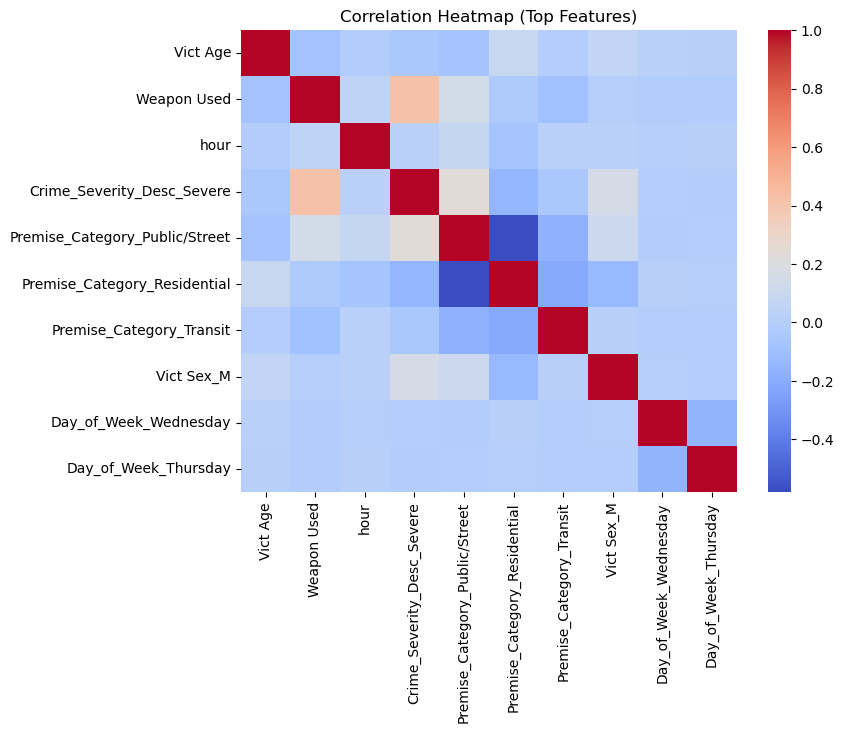

In [41]:
importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10).index

plt.figure(figsize=(8,6))
sns.heatmap(X[top_features].corr(), cmap='coolwarm', annot=False)

plt.title("Correlation Heatmap (Top Features)")
plt.show()

In [ ]:
# The correlation heatmap shows how different features are related to each other. 
# It helps identify whether any variables are strongly correlated.
# Most features show low to moderate correlation because many of them are categorical and were converted using encoding. 
# This is expected in such datasets.

In [34]:
# train test and split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6235836149537519
                                                         precision    recall  f1-score   support

         ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       1.00      1.00      1.00     10273
                               BATTERY - SIMPLE ASSAULT       0.65      0.80      0.71     14671
                                               BURGLARY       0.40      0.21      0.28      7950
                                  BURGLARY FROM VEHICLE       0.68      0.71      0.69     12306
                      INTIMATE PARTNER - SIMPLE ASSAULT       0.60      0.54      0.57      9171
                                      THEFT OF IDENTITY       0.49      0.76      0.60     12312
                     THEFT PLAIN - PETTY ($950 & UNDER)       0.39      0.35      0.37      9520
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)       0.80      0.36      0.49      9314

                                               accuracy                     

In [36]:
# random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.5900230363553446
                                                         precision    recall  f1-score   support

         ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       1.00      1.00      1.00     10273
                               BATTERY - SIMPLE ASSAULT       0.67      0.74      0.70     14671
                                               BURGLARY       0.34      0.31      0.32      7950
                                  BURGLARY FROM VEHICLE       0.60      0.63      0.62     12306
                      INTIMATE PARTNER - SIMPLE ASSAULT       0.57      0.54      0.55      9171
                                      THEFT OF IDENTITY       0.52      0.58      0.55     12312
                     THEFT PLAIN - PETTY ($950 & UNDER)       0.35      0.32      0.34      9520
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)       0.50      0.43      0.46      9314

                                               accuracy                           

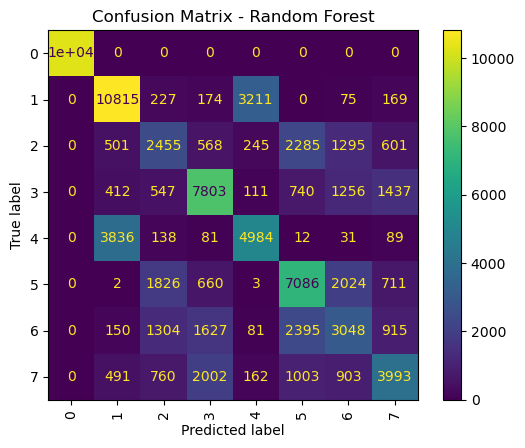

In [37]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix - Random Forest")
plt.show()

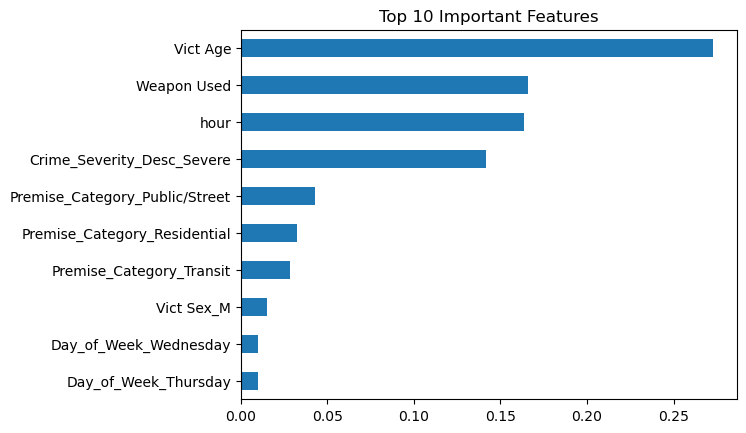

In [39]:
# feature importance
importances = model.feature_importances_

pd.Series(importances, index=X.columns)\
    .sort_values()\
    .tail(10)\
    .plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
# Conclusion & Insights
# 🔹 Conclusion
# The machine learning models were successfully applied to predict crime type using demographic, temporal, and location-based features.
# Random Forest outperformed Logistic Regression due to its ability to capture complex, non-linear relationships in the data.
# The model achieved moderate accuracy, indicating that crime patterns can be partially predicted using structured data.

In [ ]:
# 🔹 Key Insights
# Crime occurrence is significantly influenced by time of day and location
# Victim characteristics such as age and gender contribute to crime type variation
# Weapon usage helps distinguish violent crimes from non-violent ones
# Certain crime types are more likely in specific premise categories

In [ ]:
# 🔹 Connection to Statistical Analysis

# The features used in the machine learning model were selected based on prior hypothesis testing.
# Statistical tests confirmed that variables such as age, weekend occurrence, and premise category 
# have a significant relationship with crime type, which justifies their inclusion in the predictive model.